# 📊 Chest X-Ray Pneumonia Detection - Exploratory Data Analysis (EDA)

Welcome to the Exploratory Data Analysis (EDA) notebook! In this notebook, we analyze the chest X-ray dataset to understand its structural properties, class distributions, image dimensions, and medical visual markers before building deep learning models.

### 🔍 Analysis Scope:
1. **Class Distribution**: Analyze train/test split size and class imbalance (NORMAL vs. PNEUMONIA).
2. **Image Geometry Analysis**: Explore variations in image width, height, aspect ratio, and color spaces.
3. **Visual Inspection**: Display sample X-rays from both classes to identify radiological markers.
4. **Pixel Intensity Profiling**: Plot intensity histograms to compare brightness distributions.
5. **Class Average (Mean) Images**: Generate and compare the average NORMAL and PNEUMONIA scans, visualizing the anatomical differences via a subtraction image.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Set project directory on Google Drive
project_dir = '/content/drive/MyDrive/pneumonia-detection-cnn-xray'

if not os.path.exists(project_dir):
    print(f"❌ ERROR: The directory '{project_dir}' was not found in your Google Drive.")
    print("Please verify that you have uploaded the 'pneumonia-detection-cnn-xray' folder directly under 'My Drive'.")
else:
    %cd {project_dir}
    print("\n📁 Workspace Directory Contents:")
    !ls -la

Mounted at /content/drive
/content/drive/MyDrive/pneumonia-detection-cnn-xray

📁 Workspace Directory Contents:
total 1477
-rw------- 1 root root  13993 Jun 27 01:03  app.py
-rw------- 1 root root 981887 Jun 27 01:03  CheX-DS.pdf
-rw------- 1 root root  23304 Jun 27 01:03 'Confusion Matrix CheX-DS.png'
-rw------- 1 root root 403681 Jun 27 01:03  demo_screenshot.png
-rw------- 1 root root    591 Jun 27 01:03  Dockerfile
-rw------- 1 root root    159 Jun 27 01:03  .dockerignore
-rw------- 1 root root   2909 Jun 27 01:03  download_data.py
-rw------- 1 root root    207 Jun 27 01:03  .gitignore
drwx------ 2 root root   4096 Jun 27 01:04  .idea
-rw------- 1 root root   4201 Jun 27 01:03  inference.py
-rw------- 1 root root   1346 Jun 27 01:03  main.py
drwx------ 2 root root   4096 Jun 27 01:04  models
drwx------ 2 root root   4096 Jun 27 01:04  notebooks
-rw------- 1 root root   8582 Jun 27 01:03  README.md
-rw------- 1 root root   1018 Jun 27 01:03  requirements.txt
drwx------ 2 root root   

## 1. Environment Setup & Imports
Load standard visualization and image processing modules.

In [2]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Setup paths to import from 'src/'
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import DATA_DIR, IS_COLAB

print("Project Root Path:", project_root)
print("Active Data Directory:", DATA_DIR)
print("Running on Google Colab:", IS_COLAB)

Using device: cpu
Project Root Path: /content/drive/MyDrive
Active Data Directory: /content/data/chest_xray
Running on Google Colab: True


In [3]:
# Run the download and extraction script
!python download_data.py

# Verify that data files were downloaded locally
print("Local dataset structure:")
!ls -la /content/data/chest_xray
!ls -la /content/data/chest_xray/train

Downloading: 100%|#############################################| 1.14G/1.14G [01:03<00:00, 19.4MB/s]
Download complete.
Extracting /content/data/xray_dataset.tar.gz...
Extracting:   0% 0/5867 [00:00<?, ?files/s]/content/drive/MyDrive/pneumonia-detection-cnn-xray/download_data.py:74: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_path)
Extracting: 100% 5867/5867 [00:16<00:00, 346.60files/s]
Extraction complete.
Local dataset structure:
total 28
drwxr-xr-x 4 root root  4096 Jun 28 10:39 .
drwxr-xr-x 3 root root  4096 Jun 28 10:39 ..
-rw-r--r-- 1 root root 10244 Jan  6  2018 .DS_Store
drwxr-xr-x 4 root root  4096 Jun 28 10:39 test
drwxr-xr-x 4 root root  4096 Jun 28 10:39 train
total 316
drwxr-xr-x 4 root root   4096 Jun 28 10:39 .
drwxr-xr-x 4 root root   4096 Jun 28 10:39 ..
-rw-r--r-- 1 root root  14340 Jan  6  2018 .DS_Store
dr

## 2. Dataset Verification
Check if the dataset exists locally or in Colab scratch. If it's missing, download it first.

In [4]:
if not os.path.exists(DATA_DIR):
    print("⚠️ Dataset not found. Downloading and extracting...")
    # Run the download script cleanly in Python to show stdout & handle errors
    download_script = os.path.join(project_root, 'download_data.py')
    with open(download_script, 'r', encoding='utf-8') as f:
        exec(f.read())
else:
    print("✅ Dataset folder found!")

✅ Dataset folder found!


## 3. Class Distribution Analysis
Let's count the number of NORMAL and PNEUMONIA scans in each partition (Train, Test).

In [5]:
def count_classes(base_path):
    stats = {}
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue
        stats[split] = {}
        for category in ['NORMAL', 'PNEUMONIA']:
            cat_path = os.path.join(split_path, category)
            if os.path.exists(cat_path):
                stats[split][category] = len(os.listdir(cat_path))
    return stats

stats = count_classes(DATA_DIR)
if not stats or not any(stats.values()):
    raise FileNotFoundError(
        f"❌ ERROR: Dataset folder not found or empty at: '{DATA_DIR}'\n"
        "Please verify that the dataset download completed successfully in the previous cell."
    )

df_stats = pd.DataFrame(stats).T
df_stats['Total'] = df_stats['NORMAL'] + df_stats['PNEUMONIA']
df_stats['Pneumonia Ratio (%)'] = round((df_stats['PNEUMONIA'] / df_stats['Total']) * 100, 2)

print("📊 Dataset Class Statistics:")
display(df_stats)

📊 Dataset Class Statistics:


,NORMAL,PNEUMONIA,Total,Pneumonia Ratio (%)
train,1349,3884,5233,74.22
test,234,390,624,62.50


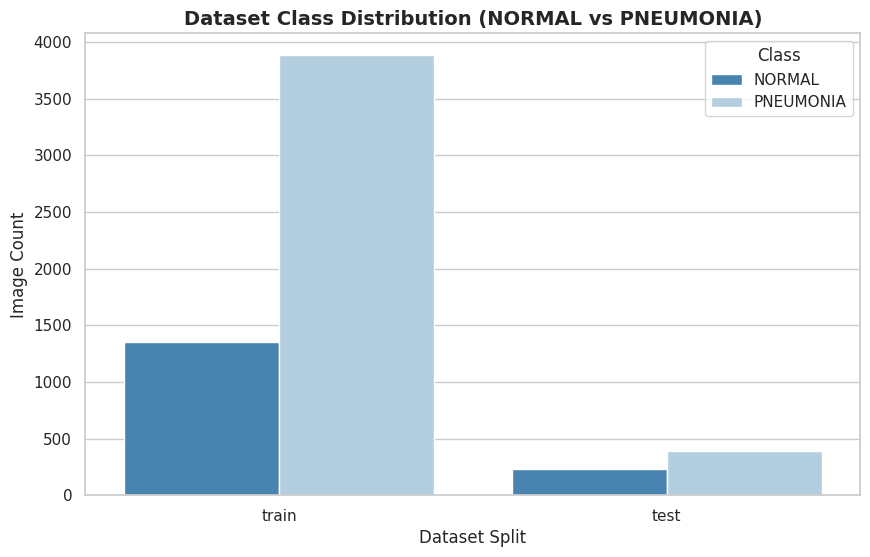

In [6]:
# Plotting the class distribution
df_melted = df_stats.reset_index().rename(columns={'index': 'Split'}).melt(
    id_vars=['Split'], value_vars=['NORMAL', 'PNEUMONIA'], var_name='Class', value_name='Count'
)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_melted, x='Split', y='Count', hue='Class', palette='Blues_r')
plt.title('Dataset Class Distribution (NORMAL vs PNEUMONIA)', fontsize=14, fontweight='bold')
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Image Count', fontsize=12)
plt.show()

> 💡 **Observation**: There is a severe **class imbalance** in the training set (~74.2% Pneumonia scans vs 25.8% Normal scans). If not addressed, the model will bias towards predicting Pneumonia. This is why our project incorporates **Weighted Asymmetric Loss (CheX-DS Loss)** to adjust training penalties based on the class ratios.

## 4. Image Geometry & Dimensions Exploration
Medical images come from various radiology systems, meaning their shapes and resolutions differ. Let's inspect resolutions.

In [7]:
def gather_image_sizes(base_path, sample_size=300):
    image_data = []
    for split in ['train']:
        for category in ['NORMAL', 'PNEUMONIA']:
            cat_path = os.path.join(base_path, split, category)
            if not os.path.exists(cat_path): continue

            filenames = os.listdir(cat_path)
            samples = random.sample(filenames, min(sample_size, len(filenames)))

            for f in samples:
                img_path = os.path.join(cat_path, f)
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                        aspect = w / h
                        channels = len(img.getbands())
                        image_data.append({
                            'class': category, 'width': w, 'height': h, 'aspect_ratio': aspect, 'channels': channels
                        })
                except Exception as e:
                    pass
    return pd.DataFrame(image_data)

df_sizes = gather_image_sizes(DATA_DIR)
print("📊 Image geometry descriptive statistics:")
display(df_sizes.describe())

📊 Image geometry descriptive statistics:


,width,height,aspect_ratio,channels
count,600.000000,600.000000,600.000000,600.000000
mean,1438.483333,1108.410000,1.366902,1.076667
std,377.039208,416.178078,0.237672,0.384320
min,457.000000,178.000000,0.953165,1.000000
25%,1184.000000,798.000000,1.189607,1.000000
50%,1430.000000,1073.000000,1.332022,1.000000
75%,1668.000000,1337.000000,1.500000,1.000000
max,2844.000000,2628.000000,2.713483,3.000000


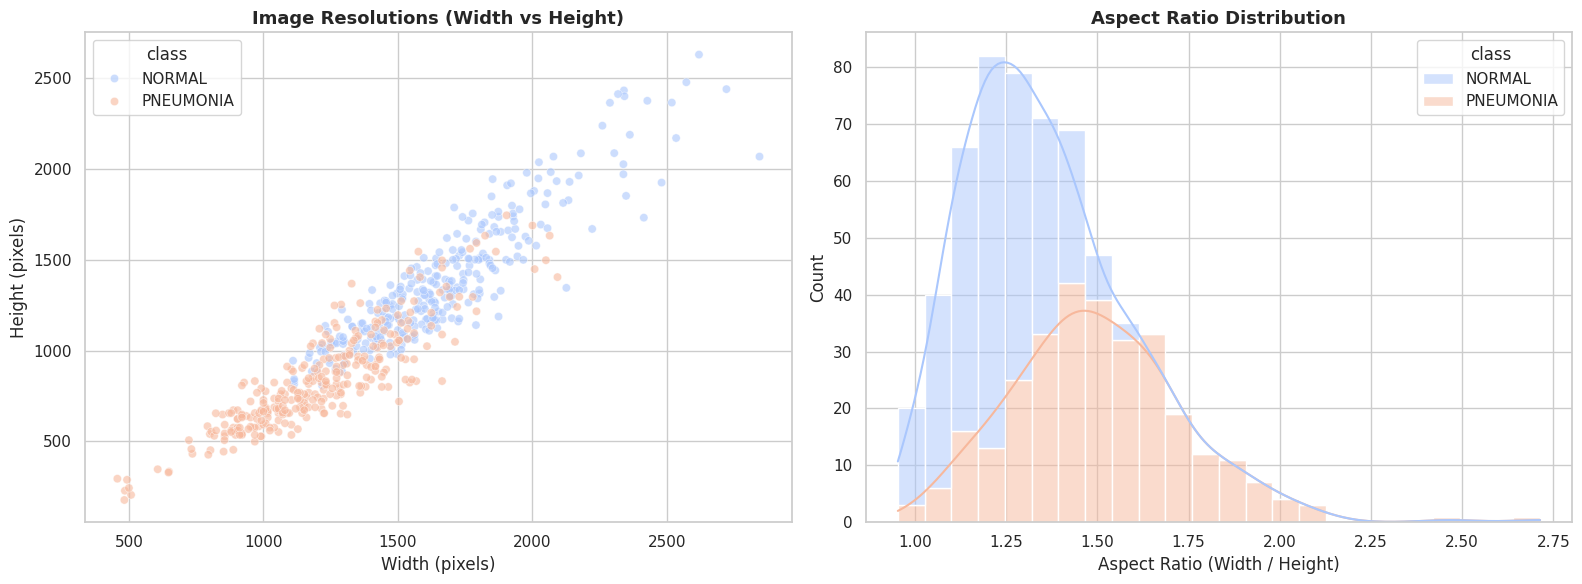

In [8]:
# Plot width vs height scatter and aspect ratio histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
sns.scatterplot(data=df_sizes, x='width', y='height', hue='class', alpha=0.6, ax=axes[0], palette='coolwarm')
axes[0].set_title('Image Resolutions (Width vs Height)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Height (pixels)')

# Aspect ratio distribution
sns.histplot(data=df_sizes, x='aspect_ratio', hue='class', kde=True, ax=axes[1], palette='coolwarm', multiple='stack')
axes[1].set_title('Aspect Ratio Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Aspect Ratio (Width / Height)')

plt.tight_layout()
plt.show()

> 💡 **Observation**: The dimensions vary wildly (ranging from ~500px to over 2000px). The aspect ratios are predominantly centered around 1.1 - 1.4 (wider than tall). Because of this variance, preprocessing steps must resize the scans to a standardized square resolution (e.g. `256 x 256`) and convert them to standard 3-channel (RGB) format before feeding them into PyTorch neural networks.

## 5. Visual Inspection of Scans (Radiological Markers)
Let's look at a grid of NORMAL chest scans side-by-side with scans showing PNEUMONIA.

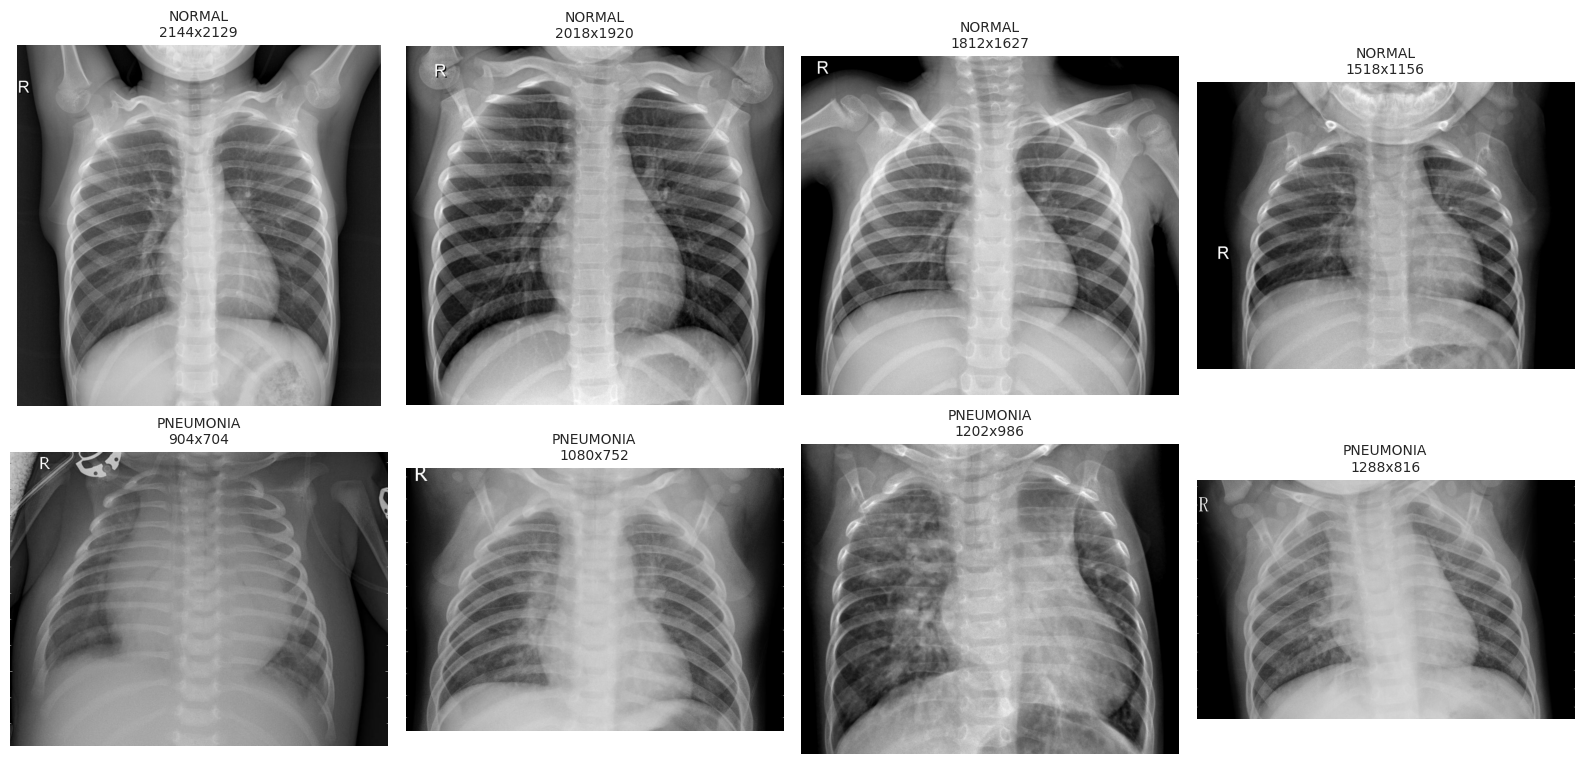

In [9]:
def plot_grid(base_path, num_samples=4):
    fig, axes = plt.subplots(2, num_samples, figsize=(16, 8))
    categories = ['NORMAL', 'PNEUMONIA']

    for row, category in enumerate(categories):
        cat_path = os.path.join(base_path, 'train', category)
        filenames = os.listdir(cat_path)
        selected = random.sample(filenames, num_samples)

        for col, f in enumerate(selected):
            img_path = os.path.join(cat_path, f)
            img = Image.open(img_path).convert('RGB')
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(category, fontsize=14, fontweight='bold')
            axes[row, col].set_title(f"{category}\n{img.size[0]}x{img.size[1]}", fontsize=10)

    plt.tight_layout()
    plt.show()

plot_grid(DATA_DIR)

### 🩺 Medical Context:
- **NORMAL**: The lungs appear clear and dark. Ribs are clearly visible, and the pleural spaces are sharp and empty.
- **PNEUMONIA**: The lung areas show blurry, cloudy, or white areas called **infiltrates** or **consolidation**. These represent fluid/accumulation inside the alveoli, indicating active infection.

## 6. Pixel Intensity Histograms
Let's check if there is a noticeable brightness/contrast difference between the two categories by reading global pixel intensity profiles.

In [10]:
def analyze_pixel_intensities(base_path, num_samples=100):
    intensities = {'NORMAL': [], 'PNEUMONIA': []}

    for category in ['NORMAL', 'PNEUMONIA']:
        cat_path = os.path.join(base_path, 'train', category)
        filenames = os.listdir(cat_path)
        selected = random.sample(filenames, min(num_samples, len(filenames)))

        for f in selected:
            img_path = os.path.join(cat_path, f)
            img = Image.open(img_path).convert('L') # Grayscale
            img_resized = img.resize((128, 128))
            arr = np.array(img_resized).flatten() / 255.0
            intensities[category].extend(arr)

    return intensities

pixel_data = analyze_pixel_intensities(DATA_DIR, num_samples=50)

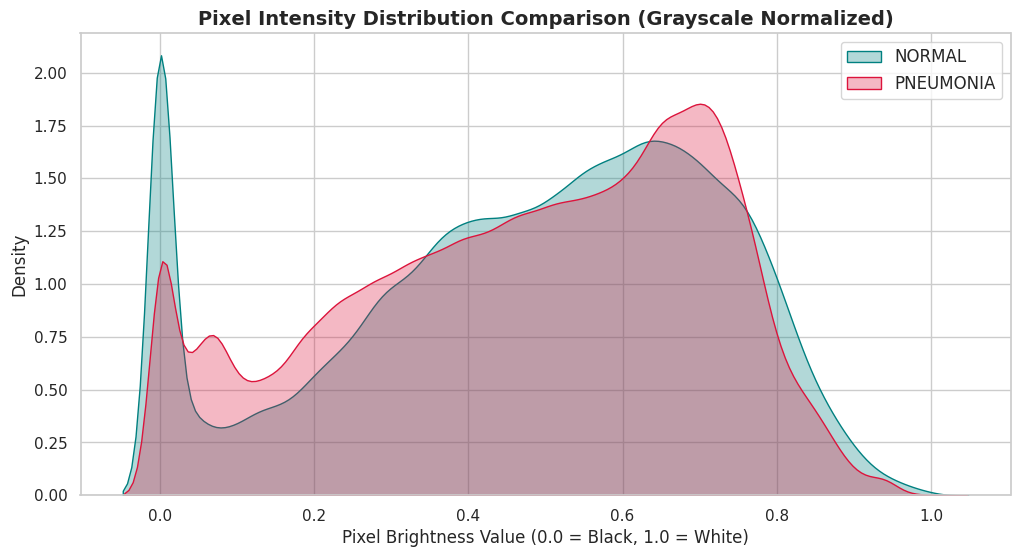

In [11]:
# Plot the intensity distribution curves
plt.figure(figsize=(12, 6))
sns.kdeplot(pixel_data['NORMAL'], color='teal', fill=True, alpha=0.3, label='NORMAL')
sns.kdeplot(pixel_data['PNEUMONIA'], color='crimson', fill=True, alpha=0.3, label='PNEUMONIA')
plt.title('Pixel Intensity Distribution Comparison (Grayscale Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Pixel Brightness Value (0.0 = Black, 1.0 = White)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.show()

> 💡 **Observation**: NORMAL scans have a slightly higher concentration of darker pixels (peaks around 0.0 - 0.2 representing empty lung space and background), while PNEUMONIA scans show a shifted curve with higher frequencies of mid-to-bright intensities (representing the fluid/infiltrate opacities).

## 7. Average Image (Mean Scan) & Subtraction Contrast
By compiling the average pixel map across many NORMAL scans and comparing it to the average PNEUMONIA scan, we can visualize the anatomical structures that differentiate the two classes.

In [12]:
def compute_mean_image(base_path, category, size=(256, 256), num_images=100):
    cat_path = os.path.join(base_path, 'train', category)
    filenames = os.listdir(cat_path)
    selected = random.sample(filenames, min(num_images, len(filenames)))

    sum_arr = np.zeros(size, dtype=np.float64)

    for f in tqdm(selected, desc=f"Averaging {category} scans"):
        img_path = os.path.join(cat_path, f)
        img = Image.open(img_path).convert('L')
        img_resized = img.resize(size)
        sum_arr += np.array(img_resized, dtype=np.float64) / 255.0

    mean_arr = sum_arr / len(selected)
    return mean_arr

mean_normal = compute_mean_image(DATA_DIR, 'NORMAL', num_images=100)
mean_pneumonia = compute_mean_image(DATA_DIR, 'PNEUMONIA', num_images=100)

Averaging PNEUMONIA scans: 100%|██████████| 100/100 [00:01<00:00, 64.13it/s]


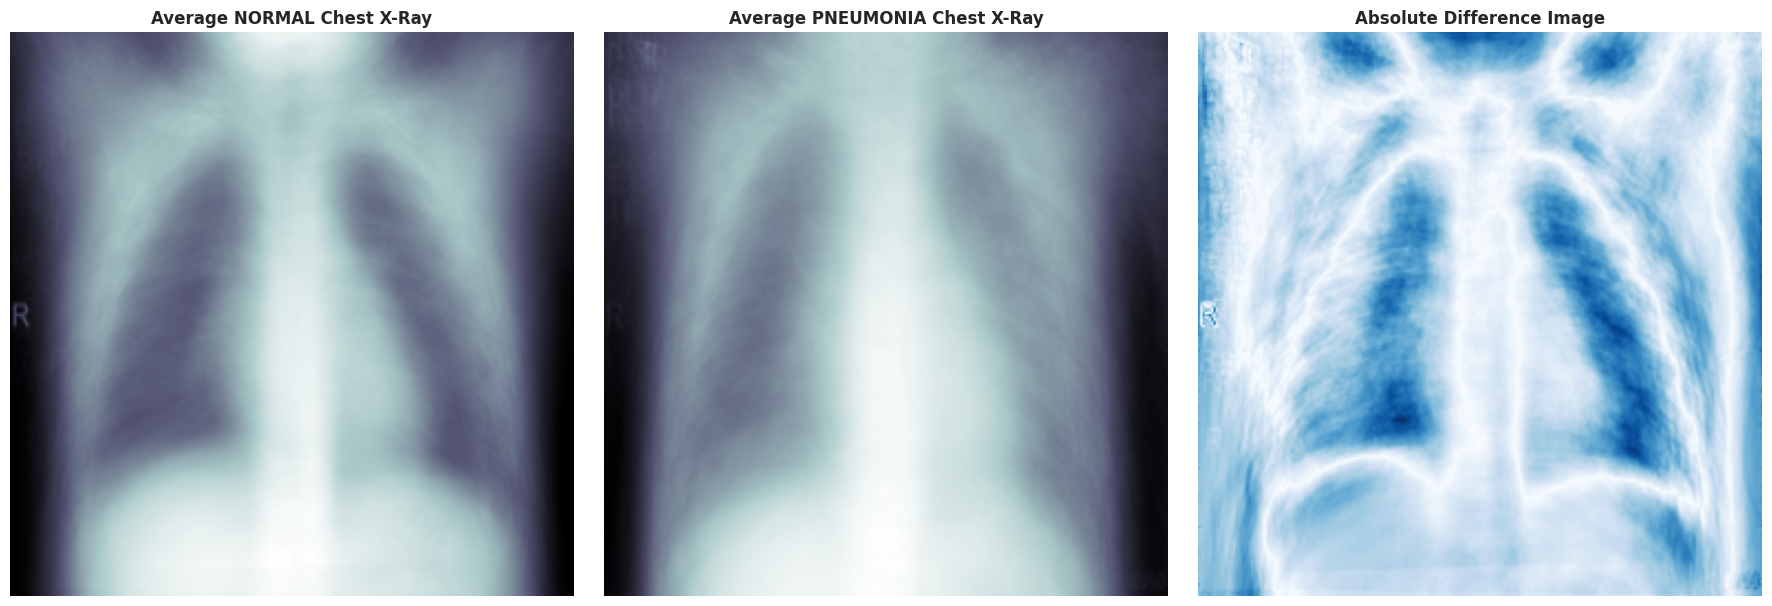

In [13]:
# Plot the average and difference images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(mean_normal, cmap='bone')
axes[0].set_title('Average NORMAL Chest X-Ray', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mean_pneumonia, cmap='bone')
axes[1].set_title('Average PNEUMONIA Chest X-Ray', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Absolute difference image
diff_image = np.abs(mean_normal - mean_pneumonia)
axes[2].imshow(diff_image, cmap='Blues')
axes[2].set_title('Absolute Difference Image', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 🩺 Medical Interpretation:
- The **Average NORMAL Image** shows a clean silhouette of the lungs with deep dark pockets.
- The **Average PNEUMONIA Image** is visibly cloudier, especially in the mid and lower lung fields.
- The **Difference Image** highlight region (in bright white/orange) represents where the scans differ most. The lungs show up bright, confirming that the classification visual markers are indeed localized inside the thoracic lung spaces and not due to artifacts like background labels or positioning.